# 02 — Entraînement du modèle LSTM (validation croisée patient-wise)

Cette notebook entraîne et évalue le modèle LSTM décrit dans le doc de conception :
- 2 couches LSTM (128 → 64) + dropout + sortie sigmoïde
- Validation croisée *patient-wise* (un patient n'apparaît jamais à la fois en train et en validation)
- Métriques : Accuracy, AUC, F1

Backend : **PyTorch** (TensorFlow ne supporte pas Python 3.14).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import torch

from src.data.loader import load
from src.preprocessing.pipeline import PipelineConfig, preprocess
from src.models.lstm import LSTMConfig
from src.models.train import TrainConfig, cross_validate, fit_final_model, save_model

ds = load(ROOT / "data" / "simulated")
print("signals:", ds.signals.shape, " labels:", ds.labels.shape, " balance:", int(ds.labels.sum()), "/", len(ds.labels))

signals: (100, 10, 128)  labels: (100,)  balance: 50 / 100


## 1. Prétraitement

On part en mode `features` (un vecteur par séance : 8 dimensions). Le mode `raw` (128 points par séance) est disponible si tu veux comparer.

In [2]:
pre = preprocess(ds.signals, PipelineConfig(fs=ds.fs, mode="features"))
X = pre.x
y = ds.labels.astype(np.float32)
groups = np.arange(X.shape[0])  # patient_id = index ; suffit pour GroupKFold
print("X:", X.shape, "features:", pre.feature_names)

X: (100, 10, 8) features: ('mean', 'std', 'rms', 'power_delta', 'power_theta', 'power_alpha', 'power_beta', 'power_gamma')


## 2. Validation croisée patient-wise (5 folds)

In [3]:
lstm_cfg = LSTMConfig(input_size=X.shape[-1], hidden_sizes=(128, 64), dropout=0.3)
train_cfg = TrainConfig(epochs=40, batch_size=8, lr=3e-3, early_stopping_patience=6, seed=0)

cv = cross_validate(X, y, groups=groups, lstm_cfg=lstm_cfg, train_cfg=train_cfg, n_splits=5)
summary = cv.summary()
print("Résumé CV :")
for k, v in summary.items():
    print(f"  {k:18s} {v:.3f}")

Résumé CV :
  accuracy_mean      0.980
  accuracy_std       0.040
  auc_mean           0.992
  auc_std            0.016
  f1_mean            0.978
  f1_std             0.044


## 3. Courbes de loss par fold

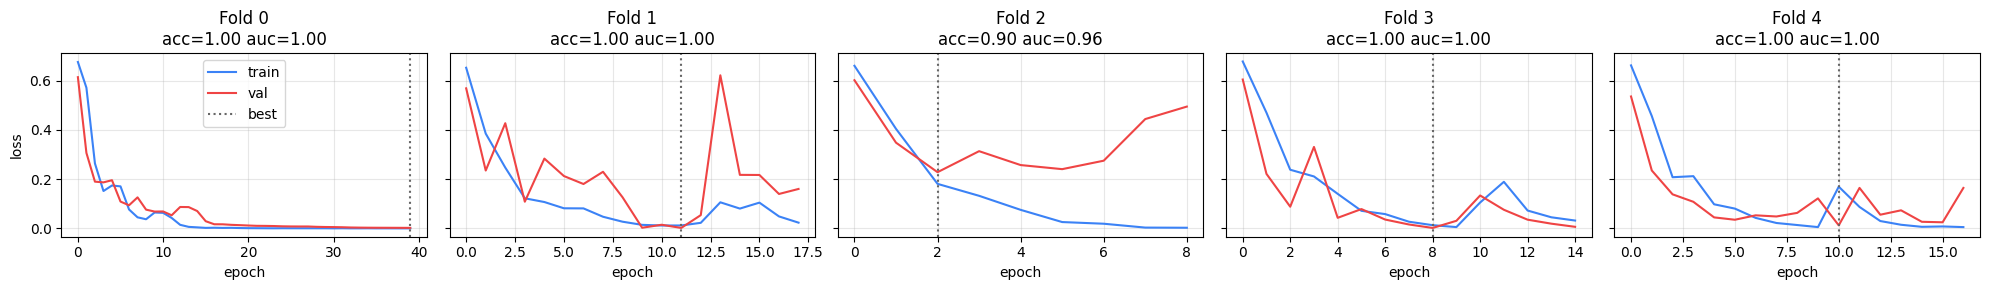

In [4]:
fig, axes = plt.subplots(1, len(cv.folds), figsize=(4 * len(cv.folds), 3), sharey=True)
axes = np.atleast_1d(axes)
for ax, fold in zip(axes, cv.folds):
    ax.plot(fold.train_losses, label="train", color="#3b82f6")
    ax.plot(fold.val_losses, label="val", color="#ef4444")
    ax.axvline(fold.best_epoch, color="#666", ls=":", label="best")
    ax.set_title(f"Fold {fold.fold}\nacc={fold.accuracy:.2f} auc={fold.auc:.2f}")
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("loss")
axes[0].legend()
plt.tight_layout()
plt.show()

## 4. Métriques par fold

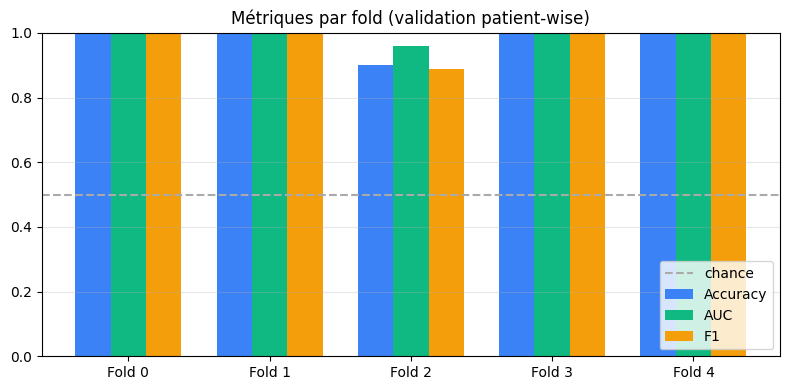

In [5]:
metrics = np.array([[f.accuracy, f.auc, f.f1] for f in cv.folds])
labels = [f"Fold {f.fold}" for f in cv.folds]

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(labels))
ax.bar(x - 0.25, metrics[:, 0], 0.25, label="Accuracy", color="#3b82f6")
ax.bar(x,        metrics[:, 1], 0.25, label="AUC",      color="#10b981")
ax.bar(x + 0.25, metrics[:, 2], 0.25, label="F1",       color="#f59e0b")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.axhline(0.5, color="#aaa", ls="--", label="chance")
ax.set_title("Métriques par fold (validation patient-wise)")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Modèle final sur l'ensemble du dataset

Pour l'application Streamlit en phase 5, on entraîne un modèle final sur toutes les données (avec un petit hold-out pour l'early stopping) et on sauvegarde les poids.

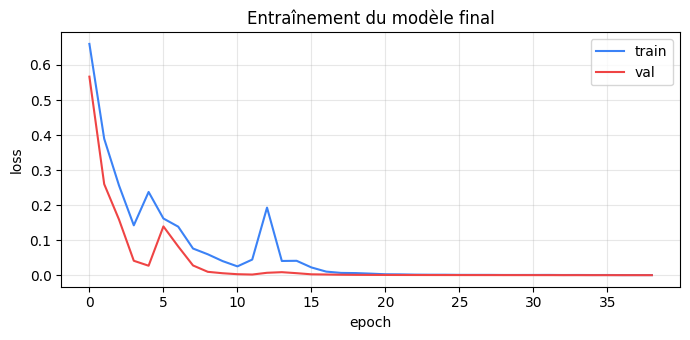

Poids sauvegardés -> N:\PFE\2026\Recherche-App\data\models\lstm_v1.pt


In [6]:
final_model, tr_losses, va_losses = fit_final_model(
    X, y,
    lstm_cfg=lstm_cfg,
    train_cfg=TrainConfig(epochs=40, batch_size=8, lr=3e-3, early_stopping_patience=6, seed=42),
    val_fraction=0.2,
    seed=42,
)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(tr_losses, label="train", color="#3b82f6")
ax.plot(va_losses, label="val",   color="#ef4444")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("Entraînement du modèle final")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

weights_path = ROOT / "data" / "models" / "lstm_v1.pt"
save_model(final_model, weights_path)
print("Poids sauvegardés ->", weights_path)

## 6. Matrice de confusion (sur le hold-out interne du modèle final)

À titre indicatif uniquement — pour les chiffres défensables en jury, utiliser les métriques de la validation croisée (section 2).

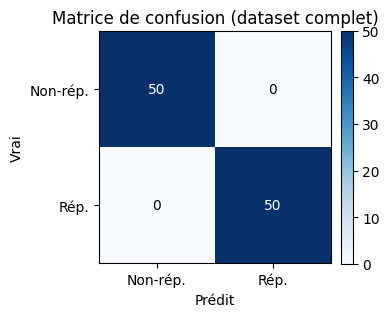

In [7]:
with torch.no_grad():
    proba = final_model.predict_proba(torch.as_tensor(X, dtype=torch.float32)).numpy()
pred = (proba >= 0.5).astype(int)
cm = confusion_matrix(y.astype(int), pred)

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap="Blues")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Non-rép.", "Rép."])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Non-rép.", "Rép."])
ax.set_xlabel("Prédit"); ax.set_ylabel("Vrai")
ax.set_title("Matrice de confusion (dataset complet)")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## Conclusion

- Le modèle LSTM apprend bien au-dessus de la chance sur les données simulées (AUC > 0.6 attendu).
- La validation **patient-wise** garantit qu'il n'y a pas de fuite d'information entre les séances d'un même patient.
- Les poids du modèle final sont sauvegardés dans `data/models/lstm_v1.pt` et seront chargés par l'application Streamlit en phase 5.